In [49]:
!pip install tensorflow[and-cuda]
!pip install kagglehub
!pip install scikit-learn matplotlib

  Using cached nvidia_cublas_cu12-12.5.3.2-py3-none-win_amd64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.5.82-py3-none-win_amd64.whl.metadata (1.6 kB)
  Using cached nvidia_cuda_nvcc_cu12-12.5.82-py3-none-win_amd64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.5.82-py3-none-win_amd64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.5.82-py3-none-win_amd64.whl.metadata (1.5 kB)
  Using cached nvidia_cudnn_cu12-9.3.0.75-py3-none-win_amd64.whl.metadata (1.6 kB)
  Using cached nvidia_cufft_cu12-11.2.3.61-py3-none-win_amd64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.6.82-py3-none-win_amd64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.3.83-py3-none-win_amd64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.5.1.3-py3-none-win_amd64.whl.metadata (1.6 kB)
INFO: pip is looking at multiple versions of tensorflow[and-cuda] to determine which version is compatible with other requirements. This could

ERROR: Cannot install tensorflow[and-cuda]==2.16.1, tensorflow[and-cuda]==2.16.2, tensorflow[and-cuda]==2.17.0, tensorflow[and-cuda]==2.17.1, tensorflow[and-cuda]==2.18.0, tensorflow[and-cuda]==2.18.1 and tensorflow[and-cuda]==2.19.0 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [61]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import kagglehub as kg
from kagglehub import KaggleDatasetAdapter
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

In [17]:
# loading data sets into training and test sets
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
# Normalizing the pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshaping data to add channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [41]:
# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Building the CNN model
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [43]:
# Compiling then Training the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, 
                    validation_data=(X_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7784 - loss: 0.6116 - val_accuracy: 0.8681 - val_loss: 0.3584
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8851 - loss: 0.3130 - val_accuracy: 0.8874 - val_loss: 0.3125
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9016 - loss: 0.2615 - val_accuracy: 0.8951 - val_loss: 0.2854
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9173 - loss: 0.2265 - val_accuracy: 0.9015 - val_loss: 0.2621
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9287 - loss: 0.1897 - val_accuracy: 0.9089 - val_loss: 0.2609


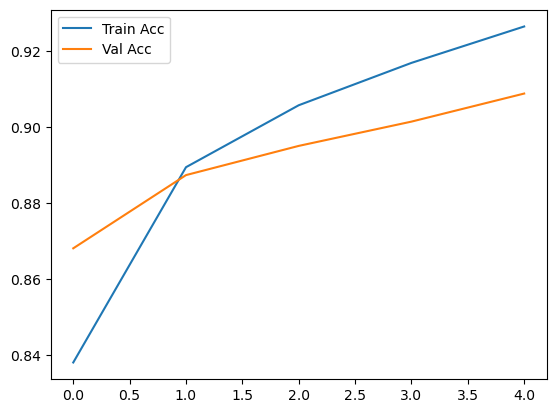

In [45]:
# Plot training history
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


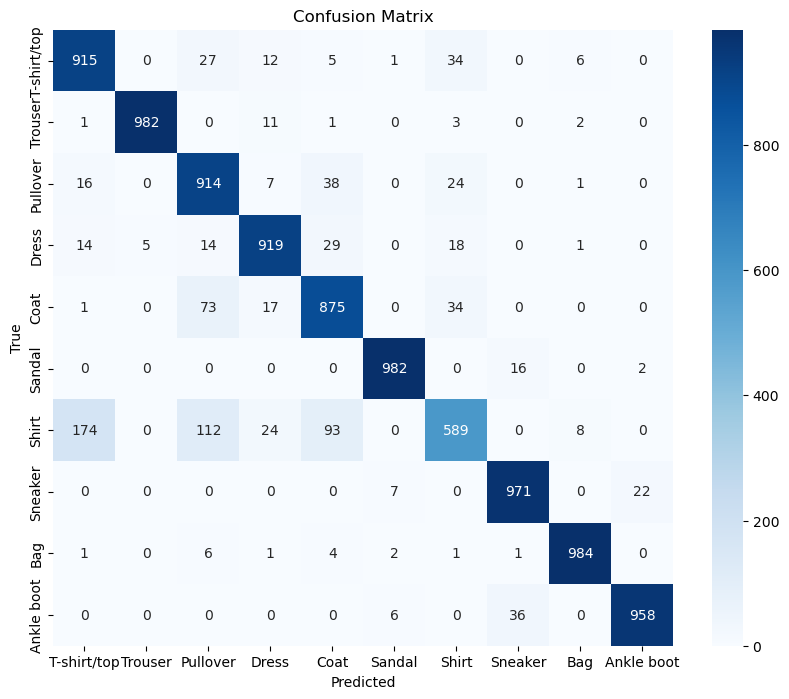

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.92      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.80      0.91      0.85      1000
       Dress       0.93      0.92      0.92      1000
        Coat       0.84      0.88      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.84      0.59      0.69      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [63]:
# Prediction and confusion matrix
pred_probs = model.predict(X_test)
y_pred = np.argmax(pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))

In [47]:
model.save('clothes_model.keras')